# Emotion Classification - 7 Classes

**Input:** Child face crops from `/classified/child/`
**Model:** DeepFace
**Classes:** Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral

## Step 1: Setup

In [1]:
!pip install deepface scikit-learn seaborn -q

from google.colab import drive
drive.mount('/content/drive')

import cv2
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from deepface import DeepFace
import warnings
warnings.filterwarnings('ignore')

print("✓ Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00
Mounted at /content/drive
26-01-10 21:07:42 - Directory /root/.deepface has been created
26-01-10 21:07:42 - Directory /root/.deepface/weights has been created
✓ Setup complete


## Step 2: Configuration

In [2]:
BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
CHILD_FOLDER = BASE_PATH / "classified/child"
EMOTION_FOLDER = BASE_PATH / "emotions_7class"
METRICS_FOLDER = BASE_PATH / "metrics"
GROUND_TRUTH_FOLDER = BASE_PATH / "ground_truth"
CHECKPOINT_FILE = BASE_PATH / "checkpoint_emotion_7class.json"

# All 7 DeepFace emotion classes
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# Create output folders for each emotion
for emotion in EMOTIONS:
    (EMOTION_FOLDER / emotion).mkdir(exist_ok=True, parents=True)

print(f"Input: {CHILD_FOLDER}")
print(f"Output: {EMOTION_FOLDER}")
print(f"Emotions: {EMOTIONS}")

Input: /content/drive/MyDrive/face_pipeline_project/classified/child
Output: /content/drive/MyDrive/face_pipeline_project/emotions_7class
Emotions: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']


## Step 3: Checkpoint Functions

In [3]:
def load_checkpoint():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, 'r') as f:
            cp = json.load(f)
            print(f"✓ Resuming: {len(cp.get('completed_videos', []))} videos done")
            return cp
    return {
        'completed_videos': [],
        'angry': 0, 'disgust': 0, 'fear': 0,
        'happy': 0, 'sad': 0, 'surprise': 0, 'neutral': 0,
        'failed': 0
    }

def save_checkpoint(cp):
    cp['last_updated'] = datetime.now().isoformat()
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(cp, f, indent=2)

checkpoint = load_checkpoint()

## Step 4: Count Child Faces

In [4]:
video_folders = sorted([f for f in CHILD_FOLDER.iterdir() if f.is_dir()])
completed = set(checkpoint['completed_videos'])
remaining = [v for v in video_folders if v.name not in completed]

total_faces = sum(len(list(f.glob("*.jpg"))) for f in video_folders)

print(f"Total child faces: {total_faces}")
print(f"Videos: {len(video_folders)} | Completed: {len(completed)} | Remaining: {len(remaining)}")

Total child faces: 6726
Videos: 31 | Completed: 0 | Remaining: 31


## Step 5: Run Emotion Classification (7 Classes)

In [5]:
classifications_file = METRICS_FOLDER / "emotion_classifications_7class.csv"
if classifications_file.exists():
    all_classifications = pd.read_csv(classifications_file).to_dict('records')
else:
    all_classifications = []

for video_folder in remaining:
    video_name = video_folder.name
    print(f"\n{'='*50}")
    print(f"Processing: {video_name}")
    print(f"{'='*50}")

    # Create output folders for this video
    for emotion in EMOTIONS:
        (EMOTION_FOLDER / emotion / video_name).mkdir(exist_ok=True)

    face_files = sorted(list(video_folder.glob("*.jpg")))
    print(f"Faces: {len(face_files)}")

    emotion_counts = {e: 0 for e in EMOTIONS}
    failed_count = 0

    for face_path in tqdm(face_files, desc="Classifying emotions"):
        try:
            # Analyze with DeepFace
            result = DeepFace.analyze(
                str(face_path),
                actions=['emotion'],
                enforce_detection=False,
                silent=True
            )

            # Get emotions
            if isinstance(result, list):
                emotions = result[0]['emotion']
                dominant = result[0]['dominant_emotion']
            else:
                emotions = result['emotion']
                dominant = result['dominant_emotion']

            # Copy to appropriate folder
            dest_folder = EMOTION_FOLDER / dominant / video_name
            shutil.copy(face_path, dest_folder / face_path.name)

            emotion_counts[dominant] += 1

            # Log with all emotion scores
            record = {
                'video': video_name,
                'face_file': face_path.name,
                'dominant_emotion': dominant
            }
            # Add all emotion scores
            for e in EMOTIONS:
                record[f'{e}_score'] = round(emotions.get(e, 0), 2)

            all_classifications.append(record)

        except Exception as e:
            failed_count += 1
            continue

    # Update checkpoint
    checkpoint['completed_videos'].append(video_name)
    for e in EMOTIONS:
        checkpoint[e] += emotion_counts[e]
    checkpoint['failed'] += failed_count
    save_checkpoint(checkpoint)

    # Print results
    print(f"\n  Results:")
    for e in EMOTIONS:
        print(f"    {e.capitalize()}: {emotion_counts[e]}")
    print(f"    Failed: {failed_count}")

    # Save after each video
    pd.DataFrame(all_classifications).to_csv(classifications_file, index=False)

print(f"\n" + "="*50)
print("✅ COMPLETE!")
print("="*50)
for e in EMOTIONS:
    print(f"  {e.capitalize()}: {checkpoint[e]}")
print(f"  Failed: {checkpoint['failed']}")


Processing: 08.56.26-09.18.33[M][0@0][107006]_ch1
Faces: 202


Classifying emotions:   0%|          | 0/202 [00:00<?, ?it/s]

26-01-10 21:07:55 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 88.2MB/s]
Classifying emotions: 100%|██████████| 202/202 [00:23<00:00,  8.46it/s]



  Results:
    Angry: 9
    Disgust: 1
    Fear: 49
    Happy: 19
    Sad: 86
    Surprise: 8
    Neutral: 30
    Failed: 0

Processing: 09.09.21-09.40.22[M][0@0][49652]_ch1
Faces: 143


...


  Results:
    Angry: 2
    Disgust: 0
    Fear: 15
    Happy: 14
    Sad: 24
    Surprise: 2
    Neutral: 12
    Failed: 0

Processing: 15.52.42-16.07.48[M][0@0][17210]_ch1
Faces: 118


Classifying emotions: 100%|██████████| 118/118 [00:10<00:00, 11.09it/s]



  Results:
    Angry: 7
    Disgust: 0
    Fear: 27
    Happy: 25
    Sad: 42
    Surprise: 3
    Neutral: 14
    Failed: 0

Processing: 16.10.25-16.37.17[M][0@0][123219]_ch1
Faces: 78


Classifying emotions: 100%|██████████| 78/78 [00:31<00:00,  2.49it/s]


  Results:
    Angry: 2
    Disgust: 0
    Fear: 8
    Happy: 7
    Sad: 42
    Surprise: 1
    Neutral: 18
    Failed: 0

✅ COMPLETE!
  Angry: 498
  Disgust: 13
  Fear: 1040
  Happy: 976
  Sad: 2839
  Surprise: 122
  Neutral: 1238
  Failed: 0


## Step 6: Emotion Distribution

Total classified: 6726

Emotion distribution:
dominant_emotion
sad         2839
neutral     1238
fear        1040
happy        976
angry        498
surprise     122
disgust       13
Name: count, dtype: int64


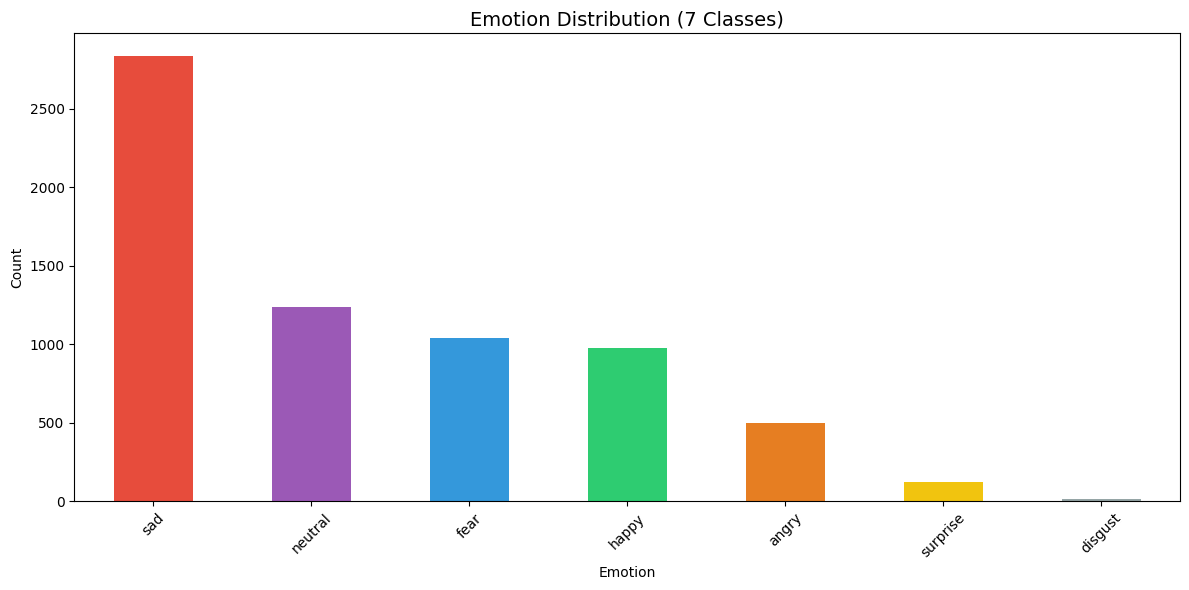

In [6]:
df = pd.read_csv(METRICS_FOLDER / "emotion_classifications_7class.csv")

print(f"Total classified: {len(df)}")
print(f"\nEmotion distribution:")
print(df['dominant_emotion'].value_counts())

# Bar chart
plt.figure(figsize=(12, 6))
colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#e67e22', '#f1c40f', '#95a5a6']
df['dominant_emotion'].value_counts().plot(kind='bar', color=colors)
plt.title('Emotion Distribution (7 Classes)', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(METRICS_FOLDER / "emotion_distribution_7class.png", dpi=150)
plt.show()

---
# 📊 VALIDATION

## Step 7: Interactive Labeling Tool

In [7]:
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets

df_class = pd.read_csv(METRICS_FOLDER / "emotion_classifications_7class.csv")

# Sample for validation
SAMPLE_SIZE = 150
df_sample = df_class.sample(n=min(SAMPLE_SIZE, len(df_class)), random_state=42).reset_index(drop=True)

print(f"Total: {len(df_class)} | Sample: {len(df_sample)}")

LABELS_FILE = GROUND_TRUTH_FOLDER / "emotion_labels_7class.csv"
labels = {}
current_idx = [0]

def save_labels():
    df_sample['actual_emotion'] = df_sample.index.map(lambda x: labels.get(x, ''))
    df_sample.to_csv(LABELS_FILE, index=False)
    return len([v for v in labels.values() if v != ''])

def show_face(idx):
    clear_output(wait=True)

    if idx >= len(df_sample):
        total = save_labels()
        print("✅ DONE!")
        print(f"Labeled: {total}")
        return

    row = df_sample.iloc[idx]
    img_path = CHILD_FOLDER / row['video'] / row['face_file']

    labeled_count = len([v for v in labels.values() if v != ''])

    print(f"Image {idx+1}/{len(df_sample)}  |  Labeled: {labeled_count}")
    print(f"DeepFace says: {row['dominant_emotion'].upper()}")
    print(f"Scores: ", end="")
    for e in EMOTIONS:
        score = row.get(f'{e}_score', 0)
        print(f"{e[:3]}:{score:.0f}% ", end="")
    print()

    if img_path.exists():
        display(IPImage(filename=str(img_path)))
    else:
        print(f"❌ Not found")

    # Create buttons for all 7 emotions
    btn_angry = widgets.Button(description="😠 Angry", button_style='danger', layout=widgets.Layout(width='100px'))
    btn_disgust = widgets.Button(description="🤢 Disgust", button_style='warning', layout=widgets.Layout(width='100px'))
    btn_fear = widgets.Button(description="😨 Fear", button_style='info', layout=widgets.Layout(width='100px'))
    btn_happy = widgets.Button(description="😊 Happy", button_style='success', layout=widgets.Layout(width='100px'))
    btn_sad = widgets.Button(description="😢 Sad", button_style='primary', layout=widgets.Layout(width='100px'))
    btn_surprise = widgets.Button(description="😲 Surprise", button_style='warning', layout=widgets.Layout(width='100px'))
    btn_neutral = widgets.Button(description="😐 Neutral", layout=widgets.Layout(width='100px'))

    btn_skip = widgets.Button(description="Skip", layout=widgets.Layout(width='80px'))
    btn_back = widgets.Button(description="← Back", layout=widgets.Layout(width='80px'))
    btn_save = widgets.Button(description="💾 Save", button_style='success', layout=widgets.Layout(width='80px'))

    def make_handler(emotion):
        def handler(b):
            labels[idx] = emotion
            current_idx[0] += 1
            show_face(current_idx[0])
        return handler

    btn_angry.on_click(make_handler('angry'))
    btn_disgust.on_click(make_handler('disgust'))
    btn_fear.on_click(make_handler('fear'))
    btn_happy.on_click(make_handler('happy'))
    btn_sad.on_click(make_handler('sad'))
    btn_surprise.on_click(make_handler('surprise'))
    btn_neutral.on_click(make_handler('neutral'))

    def on_skip(b): current_idx[0] += 1; show_face(current_idx[0])
    def on_back(b):
        if current_idx[0] > 0 and idx in labels:
            del labels[idx]
            current_idx[0] -= 1
            show_face(current_idx[0])
    def on_save(b): save_labels(); print(f"💾 Saved {len(labels)} labels")

    btn_skip.on_click(on_skip)
    btn_back.on_click(on_back)
    btn_save.on_click(on_save)

    display(widgets.HBox([btn_angry, btn_disgust, btn_fear, btn_happy]))
    display(widgets.HBox([btn_sad, btn_surprise, btn_neutral]))
    display(widgets.HBox([btn_skip, btn_back, btn_save]))

print("🏁 Starting...")
show_face(0)

✅ DONE!
Labeled: 150


## Step 8: Confusion Matrix (7 Classes)

Labeled: 150


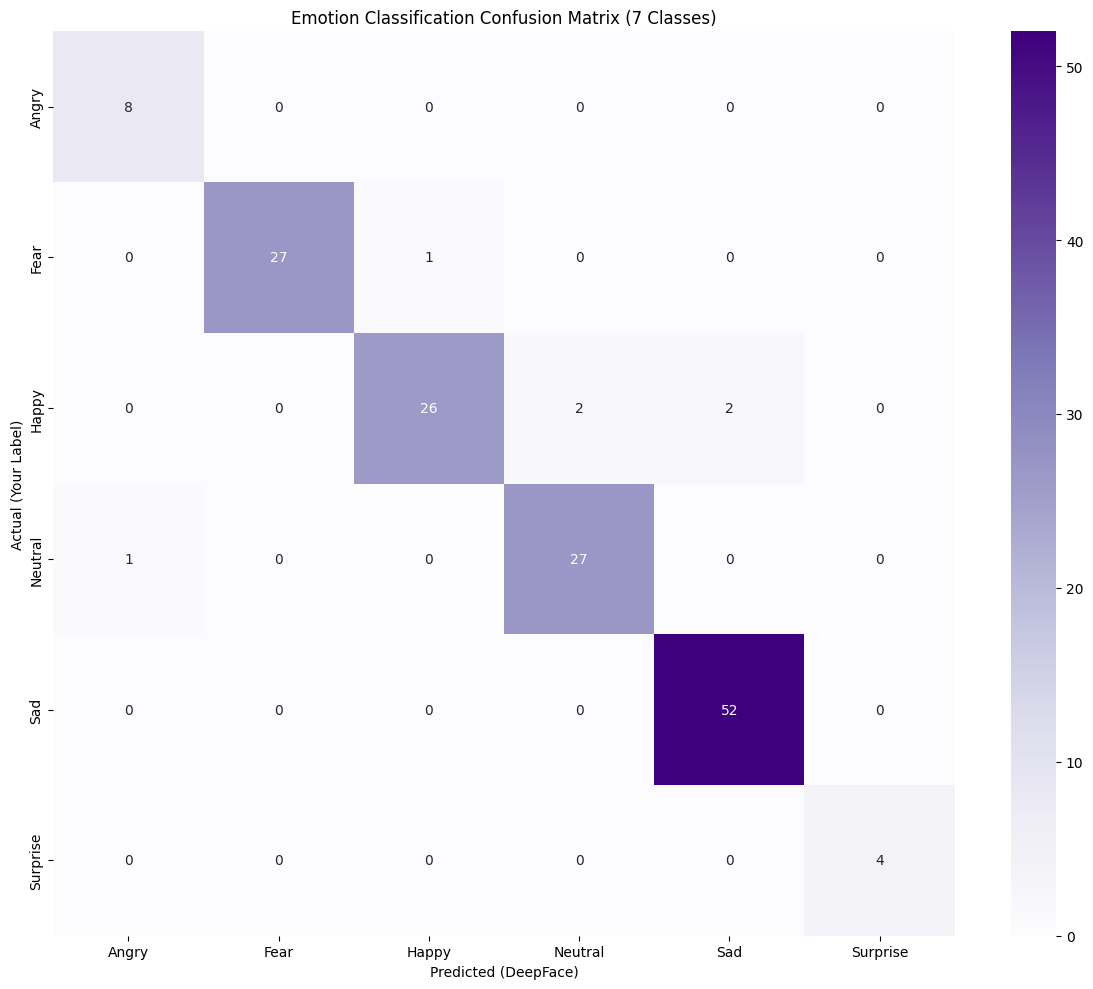


              precision    recall  f1-score   support

       Angry       0.89      1.00      0.94         8
        Fear       1.00      0.96      0.98        28
       Happy       0.96      0.87      0.91        30
     Neutral       0.93      0.96      0.95        28
         Sad       0.96      1.00      0.98        52
    Surprise       1.00      1.00      1.00         4

    accuracy                           0.96       150
   macro avg       0.96      0.97      0.96       150
weighted avg       0.96      0.96      0.96       150


Overall Accuracy: 96.0%


In [10]:
LABELS_FILE = GROUND_TRUTH_FOLDER / "emotion_labels_7class.csv"

try:
    df_gt = pd.read_csv(LABELS_FILE)
    df_labeled = df_gt[df_gt['actual_emotion'].notna() & (df_gt['actual_emotion'] != '')].copy()

    if len(df_labeled) == 0:
        print("⚠️ No labels! Run Step 7 first.")
    else:
        print(f"Labeled: {len(df_labeled)}")

        y_true = df_labeled['actual_emotion'].values
        y_pred = df_labeled['dominant_emotion'].values

        # Only use labels that appear in the data
        present_labels = sorted(list(set(y_true) | set(y_pred)))

        cm = confusion_matrix(y_true, y_pred, labels=present_labels)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                    xticklabels=[e.capitalize() for e in present_labels],
                    yticklabels=[e.capitalize() for e in present_labels])
        plt.xlabel('Predicted (DeepFace)')
        plt.ylabel('Actual (Your Label)')
        plt.title('Emotion Classification Confusion Matrix (7 Classes)')
        plt.tight_layout()
        plt.savefig(METRICS_FOLDER / "confusion_matrix_emotion_7class.png", dpi=150)
        plt.show()

        print("\n" + "="*60)
        print(classification_report(y_true, y_pred, labels=present_labels,
                                    target_names=[e.capitalize() for e in present_labels],
                                    zero_division=0))

        accuracy = (y_true == y_pred).mean()
        print(f"\nOverall Accuracy: {accuracy:.1%}")

except FileNotFoundError:
    print("⚠️ Run Step 7 first!")